$$\phi_i = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|! (M - |S| - 1)!}{M!} [f(S \cup \{i\}) - f(S)]$$

In [5]:
import xgboost
import shap
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing

### ----- Load data ----- 

In [ ]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names) # type: ignore
y = data.target # type: ignore
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### ----- Train an XGBoost model ----- 

In [ ]:
model = xgboost.XGBRegressor().fit(X_train, y_train)

In [8]:
# TreeExplainer is optimized for gradient boosted trees
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

### ----- Visualizations ----- 

Summary Plot: Vertical axis is feature, horizontal is SHAP value (impact).


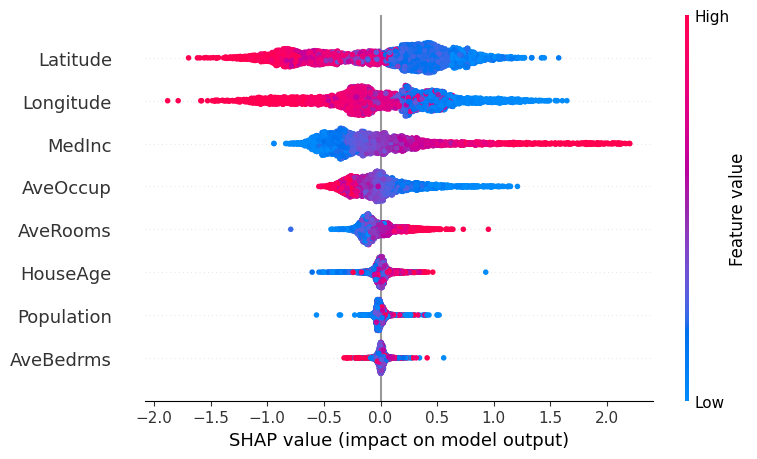

Waterfall Plot: Shows how we got from the base value to the final prediction.


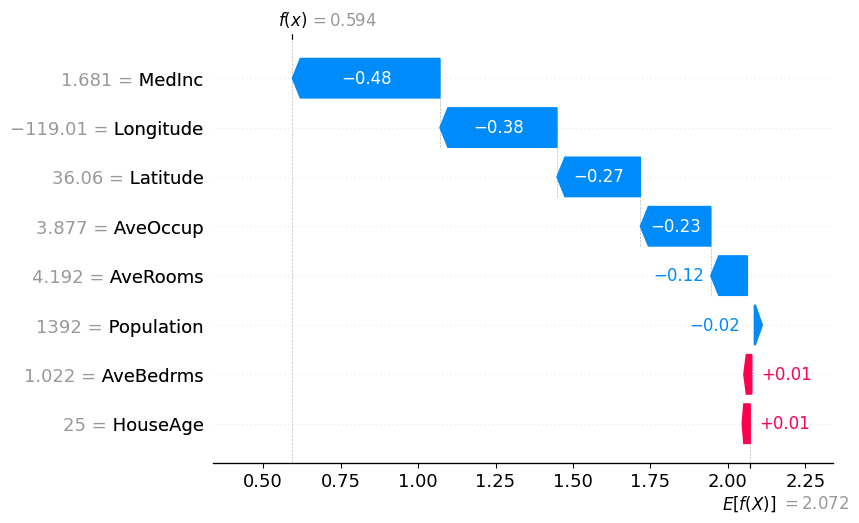

In [9]:
# A. Summary Plot: Global importance and direction
print("Summary Plot: Vertical axis is feature, horizontal is SHAP value (impact).")
shap.summary_plot(shap_values, X_test)

# B. Waterfall Plot: Explaining a single specific prediction (the first house in test set)
print("Waterfall Plot: Shows how we got from the base value to the final prediction.")
# Note: For newer SHAP versions, use the Explanation object
exp = explainer(X_test)
shap.plots.waterfall(exp[0])